In [1]:
from __future__ import annotations
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc
from typing import Dict, Tuple
import sys

import torch
from torch_geometric.data import HeteroData

/home/biffon/.conda/envs/phage_host_env_gnn_model/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running inference on: {device}")

Running inference on: cuda


In [3]:
# DIRS & CONFIGS
TRAINED_MODELS_DIR = Path("PH_trained_models")
CV_RESULTS_DIR = Path("PH_q_LOGOCV_results")
CLUSTER_DIR = Path("new_strains_assignment_results/15new_strains_assigned_clusters")
INFERENCE_OUT_DIR = Path("inference_n_inVitro_benchmark/inference_predictions_NEW1")
FIG_DIR = INFERENCE_OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
INFERENCE_OUT_DIR.mkdir(parents=True, exist_ok=True)

ASSIGNMENT_CSV = (CLUSTER_DIR / "15new_strains_highest_supported_quantile_by_model.csv")


K_PHAGE_PHAGE = 10
K_HOST_HOST = 10
PHAGE_MP = ("phage", "similar_to", "phage")
HOST_MP = ("host", "similar_to", "host")

MODEL_NAMES = ["AF3", "ESM2", "ESMC", "LucaOne", "BacFormer"]
Q_LIST = [0.999, 0.995, 0.990, 0.950, 0.900, 0.850, 0.800, 0.750]

In [4]:
#loading quantile assignments for the 15 new strains
assignment_df = pd.read_csv(ASSIGNMENT_CSV)
assignment_df["quantile"] = pd.to_numeric(assignment_df["quantile"], errors="coerce")
candidate_routes_df = assignment_df[
    (assignment_df["support_status"] == "supported") &
    (assignment_df["model"].isin(MODEL_NAMES))
].copy()

print("Supported model-strain routes:", len(candidate_routes_df))
display(candidate_routes_df.head())
display(assignment_df.groupby("model")["support_status"].value_counts()) # strain support by the model

Supported model-strain routes: 74


,model,host_id,max_similarity,quantile,support_status
0,ESM2,IM001,0.999909,0.995,supported
1,ESM2,IM018,0.906610,0.900,supported
2,ESM2,IM043,0.999989,0.999,supported
3,ESM2,IM061_1,0.999976,0.999,supported
5,ESM2,IM074,0.725003,0.750,supported


model      support_status
AF3        supported         15
BacFormer  supported         15
ESM2       supported         14
           no_support         1
ESMC       supported         15
LucaOne    supported         15
Name: count, dtype: int64

In [5]:
candidate_routes_df.groupby(["model", "quantile"]).size()

model      quantile
AF3        0.900       7
           0.995       8
BacFormer  0.850       1
           0.900       3
           0.950       3
           0.990       3
           0.995       2
           0.999       3
ESM2       0.750       2
           0.900       3
           0.950       1
           0.990       1
           0.995       1
           0.999       6
ESMC       0.900       7
           0.950       8
LucaOne    0.900       4
           0.950       3
           0.990       8
dtype: int64

In [6]:
#extracing host-unseen LOGOCV metrics for routing (Primary metric: AUPRC, Tie breaker: Hit@10)
cv_results = []
for model in MODEL_NAMES:
    model_dir = CV_RESULTS_DIR / f"{model}_results_raw"
    for q in Q_LIST:
        pickle_file = (model_dir / f"logocv_results_{model}_q_{q:.3f}.pickle")
        if not pickle_file.exists():
            continue

        with open(pickle_file, "rb") as f:
            result = pickle.load(f)

        cv_results.append(
            {
                "model": model,
                "quantile": float(result["q"]),
                "pooled_ap": float(result["pooled_ap"]),
                "mean_hit10": float(result["mean_hit_curve"][9])
            }
        )

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

,model,quantile,pooled_ap,mean_hit10
0,AF3,0.999,0.763033,0.834711
1,AF3,0.995,0.769216,0.826446
2,AF3,0.990,0.772801,0.809917
3,AF3,0.950,0.693657,0.826446
4,AF3,0.900,0.740509,0.834711
5,AF3,0.850,0.707503,0.834711
6,AF3,0.800,0.740536,0.793388
7,AF3,0.750,0.729488,0.851240
8,ESM2,0.999,0.742756,0.826446
9,ESM2,0.995,0.737706,0.809917


In [7]:
# attaching CV performance to each possible model-quantile route
candidate_routes_df = candidate_routes_df.merge(cv_results_df, on=["model", "quantile"], how="left")
missing_routes = candidate_routes_df[candidate_routes_df["pooled_ap"].isna()]
print("Routes without CV metrics:", len(missing_routes))
display(candidate_routes_df.head())

Routes without CV metrics: 0


,model,host_id,max_similarity,quantile,support_status,pooled_ap,mean_hit10
0,ESM2,IM001,0.999909,0.995,supported,0.737706,0.809917
1,ESM2,IM018,0.906610,0.900,supported,0.509886,0.818182
2,ESM2,IM043,0.999989,0.999,supported,0.742756,0.826446
3,ESM2,IM061_1,0.999976,0.999,supported,0.742756,0.826446
4,ESM2,IM074,0.725003,0.750,supported,0.537580,0.826446


In [8]:
# selecting final inference route per strain (based on highest AUPRC first, Hit@10 used as tie breaker)
final_routing_df = (
    candidate_routes_df
    .sort_values(["host_id", "pooled_ap", "mean_hit10"], ascending=[True, False, False])
    .drop_duplicates("host_id")
    .rename(
        columns={
            "model": "selected_model",
            "quantile": "selected_quantile",
            "pooled_ap": "selected_cv_auprc",
            "mean_hit10": "selected_cv_hit10"
        }
    )

    [
        [
            "host_id",
            "selected_model",
            "selected_quantile",
            "selected_cv_auprc",
            "selected_cv_hit10"
        ]
    ]
    .reset_index(drop=True)
)

print("Final routed strains:", len(final_routing_df))
display(final_routing_df)

Final routed strains: 15


,host_id,selected_model,selected_quantile,selected_cv_auprc,selected_cv_hit10
0,IM001,BacFormer,0.990,0.774667,0.851240
1,IM018,AF3,0.900,0.740509,0.834711
2,IM043,BacFormer,0.990,0.774667,0.851240
3,IM061_1,BacFormer,0.995,0.774684,0.859504
4,IM066,AF3,0.900,0.740509,0.834711
5,IM074,AF3,0.900,0.740509,0.834711
6,IM085,AF3,0.900,0.740509,0.834711
7,IM088,AF3,0.900,0.740509,0.834711
8,IM094,AF3,0.900,0.740509,0.834711
9,IM_023,BacFormer,0.995,0.774684,0.859504


In [9]:
#validating final routing completeness
expected_hosts = assignment_df["host_id"].nunique()
print("Expected strains:", expected_hosts)
print("Assigned strains:", final_routing_df["host_id"].nunique())
print("Duplicate strains:", final_routing_df["host_id"].duplicated().sum())

display(final_routing_df["selected_model"].value_counts())
display(final_routing_df.groupby(["selected_model", "selected_quantile"]).size().reset_index(name="n_strains"))
final_routing_df.to_csv(INFERENCE_OUT_DIR / "15new_strains_final_model_routing.csv", index=False)

Expected strains: 15
Assigned strains: 15
Duplicate strains: 0


selected_model
BacFormer    8
AF3          7
Name: count, dtype: int64

,selected_model,selected_quantile,n_strains
0,AF3,0.900,7
1,BacFormer,0.990,3
2,BacFormer,0.995,2
3,BacFormer,0.999,3


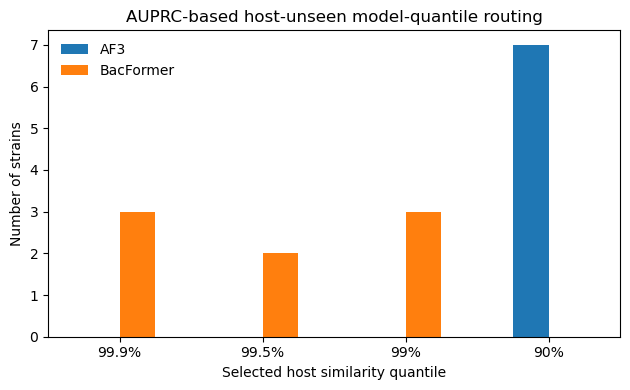

In [10]:
# visualizing selected model-quantile assignments

routing_plot_df = (final_routing_df.groupby(["selected_quantile", "selected_model"]).size().unstack(fill_value=0).sort_index(ascending=False))

# keeping only quantiles assigned to at least one strain
routing_plot_df = routing_plot_df.loc[routing_plot_df.sum(axis=1) > 0]

fig, ax = plt.subplots(figsize=(6.4, 4.0))
routing_plot_df.plot(kind="bar", ax=ax)
ax.set_xlabel("Selected host similarity quantile")
ax.set_ylabel("Number of strains")
ax.set_title("AUPRC-based host-unseen model-quantile routing")
ax.legend(frameon=False)
ax.set_xticklabels([f"{q * 100:g}%" for q in routing_plot_df.index], rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "host_unseen_AUPRC_based_model_quantile_routing.png", dpi=500, bbox_inches="tight")
fig.savefig(FIG_DIR / "host_unseen_AUPRC_based_model_quantile_routing.pdf", dpi=600, bbox_inches="tight", pad_inches=0.02)
plt.show()

Model-specific inference for 15 new strains against 27 training phages.

Each strain is scored using the model-quantile checkpoint selected from its highest supported similarity regime and corresponding host-unseen CV AUPRC.

In [11]:
#defining model-specific phage, training-host, and new-host embedding files
DATA_DIR = Path("training_host_embeddings")
IN_VITRO_DATA_DIR = Path("inVitro_data")

EMBEDDING_PATHS = {
    "ESM2": {
        "phage": IN_VITRO_DATA_DIR / "PH_15strains_embeddings/ESM2/phage_rbp_esm2_colmean_embeddings_27phages.csv",
        "train_host": DATA_DIR / "host_klocus_esm2_colmean_embeddings.csv",
        "new_host": IN_VITRO_DATA_DIR / "PH_15strains_embeddings/ESM2/k_loci_ESM2_invitro_15strains_colmean_embeddings.csv",
    },
    "ESMC": {
        "phage": IN_VITRO_DATA_DIR / "PH_15strains_embeddings/ESMC/phage_rbp_esmc_colmean_embeddings_27phages.csv",
        "train_host": DATA_DIR / "host_klocus_esmc_colmean_embeddings.csv",
        "new_host": IN_VITRO_DATA_DIR / "PH_15strains_embeddings/ESMC/k_loci_ESMC_invitro_15strains_colmean_embeddings.csv",
    },
    "LucaOne": {
        "phage": IN_VITRO_DATA_DIR / "PH_15strains_embeddings/LucaOne/phage_rbp_lucaone_colmean_embeddings_27phages.csv",
        "train_host": DATA_DIR / "host_klocus_lucaone_colmean_embeddings.csv",
        "new_host": IN_VITRO_DATA_DIR / "PH_15strains_embeddings/LucaOne/k_loci_LucaOne_inVitro_15strains_colmean_embeddings.csv",
    },
    "AF3": {
        "phage": IN_VITRO_DATA_DIR / "PH_15strains_embeddings/AF3/PH_esm_if1_rbpbase_af3_structural_embeddings_col_mean_27phages.csv",
        "train_host": DATA_DIR / "PH_esm_if1_locibase_af3_structural_embeddings_col_mean.csv",
        "new_host": IN_VITRO_DATA_DIR / "PH_15strains_embeddings/AF3/15strains_esm_if1_locibase_af3_structural_embeddings_col_mean.csv",
    },
    "BacFormer": {
        "phage": IN_VITRO_DATA_DIR / "PH_15strains_embeddings/BacFormer/RBPbase_colWmean_bacformer_embeddings_27phages.csv",
        "train_host": DATA_DIR / "Locibase_colWmean_bacformer_embeddings.csv",
        "new_host": IN_VITRO_DATA_DIR / "PH_15strains_embeddings/BacFormer/Locibase_colWmean_bacformer_embeddings_15strains.csv",
    },
}

In [12]:
# checking the model-quantile routes and required model-specific embedding files

required_routes = final_routing_df.groupby(["selected_model", "selected_quantile"]).size().reset_index(name="n_strains")
required_models = sorted(final_routing_df["selected_model"].unique())

display(required_routes)
print("Models required for inference:", required_models)

embedding_file_rows = []
for model_name in required_models:
    if model_name not in EMBEDDING_PATHS:
        raise KeyError(f"Embedding paths are not configured for {model_name}.")

    for embedding_type, file_path in EMBEDDING_PATHS[model_name].items():
        embedding_file_rows.append({"model": model_name, "embedding_type": embedding_type, "file": file_path, "exists": file_path.exists()})

embedding_files_df = pd.DataFrame(embedding_file_rows)
display(embedding_files_df)

if not embedding_files_df["exists"].all():
    raise FileNotFoundError("One or more required embedding files are missing. Check EMBEDDING_PATHS.")

,selected_model,selected_quantile,n_strains
0,AF3,0.900,7
1,BacFormer,0.990,3
2,BacFormer,0.995,2
3,BacFormer,0.999,3


Models required for inference: ['AF3', 'BacFormer']


,model,embedding_type,file,exists
0,AF3,phage,inVitro_data/PH_15strains_embeddings/AF3/PH_es...,True
1,AF3,train_host,training_host_embeddings/PH_esm_if1_locibase_a...,True
2,AF3,new_host,inVitro_data/PH_15strains_embeddings/AF3/15str...,True
3,BacFormer,phage,inVitro_data/PH_15strains_embeddings/BacFormer...,True
4,BacFormer,train_host,training_host_embeddings/Locibase_colWmean_bac...,True
5,BacFormer,new_host,inVitro_data/PH_15strains_embeddings/BacFormer...,True


In [13]:
# helper functions (embedding loading and validation)

def _strip_str_index(idx: pd.Index) -> pd.Index:
    return pd.Index([str(x).strip() for x in idx])

def load_embeddings(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, index_col=0)
    df.index = _strip_str_index(df.index)
    df = df.apply(pd.to_numeric, errors="coerce")

    if df.index.duplicated().any():
        duplicated_ids = df.index[df.index.duplicated()].unique().tolist()
        raise ValueError(f"Duplicate embedding IDs in {csv_path}: {duplicated_ids[:10]}")

    if df.isna().any().any():
        raise ValueError(f"Missing or non-numeric embedding values detected in {csv_path}.")

    return df

In [14]:
# Graph construction helper functions
# For every target node, select its top-k most similar allowed source nodes.
# edge_index[0] = source node
# edge_index[1] = target node

def build_heterodata(phage_x: torch.Tensor, host_x: torch.Tensor, phage_edges: torch.Tensor, host_edges: torch.Tensor) -> HeteroData:

    data = HeteroData()
    data["phage"].x = phage_x
    data["host"].x = host_x

    data[PHAGE_MP].edge_index = phage_edges
    data[HOST_MP].edge_index = host_edges

    print("\nGraph summary")
    print("Node types:", data.node_types)
    print("Message-passing edge types:", data.edge_types)

    for edge_type in data.edge_types:
        n_edges = data[edge_type].edge_index.size(1)
        print(f"{edge_type}: {n_edges:,} edges")

    return data


def same_type_knn_edges(X: np.ndarray, k: int = 10, source_mask: np.ndarray | None = None, target_mask: np.ndarray | None = None) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    n_nodes = X.shape[0]
    if n_nodes <= 1:
        return np.zeros((2, 0), dtype=np.int64)

    # normalizing so the dot product equals cosine similarity
    X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    similarity = X_norm @ X_norm.T

    # preventing self-connections
    np.fill_diagonal(similarity, -np.inf)

    if source_mask is None:
        source_idx = np.arange(n_nodes)
    else:
        source_mask = np.asarray(source_mask, dtype=bool)

        if source_mask.size != n_nodes:
            raise ValueError("source_mask must match the number of nodes")

        source_idx = np.flatnonzero(source_mask)

    if target_mask is None:
        target_idx = np.arange(n_nodes)
    else:
        target_mask = np.asarray(target_mask, dtype=bool)

        if target_mask.size != n_nodes:
            raise ValueError("target_mask must match the number of nodes.")

        target_idx = np.flatnonzero(target_mask)

    if source_idx.size == 0 or target_idx.size == 0:
        return np.zeros((2, 0), dtype=np.int64)

    edges = []
    # Match training: choose the nearest allowed sources for each target
    for target in target_idx:
        candidate_sources = source_idx[source_idx != target]
        if candidate_sources.size == 0:
            continue

        target_scores = similarity[target, candidate_sources]
        current_k = min(max(1, int(k)), candidate_sources.size)
        top_local = np.argpartition(-target_scores, current_k - 1)[:current_k]

        selected_sources = candidate_sources[top_local]
        for source in selected_sources:
            edges.append((int(source), int(target)))

    if not edges:
        return np.zeros((2, 0), dtype=np.int64)

    return np.asarray(edges, dtype=np.int64).T

In [15]:
# function for scoring 17 training phages against one new strain
@torch.no_grad()
def score_all_phages(z: Dict[str, torch.Tensor], model, host_idx: int, nphage: int) -> np.ndarray:
    dev = z["phage"].device
    ph = torch.arange(nphage, device=dev)
    ho = torch.full((nphage,), int(host_idx), device=dev)
    ei = torch.stack([ph, ho], dim=0)
    logits = model.decode(z, ei)
    return torch.sigmoid(logits).detach().cpu().numpy().astype(np.float32)

In [16]:
#loading the model GNN architecture used in the saved model checkpoints
sys.path.append("../../a_models")
from GNN_model_inductive import Model
print("GNN model class loaded!")

GNN model class loaded!


In [17]:
# resolving the checkpoint, scaler, and metadata files for the one selected model-quantile route
def resolve_trained_files(model_name: str, q: float) -> Dict[str, Path]:
    model_root = TRAINED_MODELS_DIR / model_name / "best_models_per_q_NEW"
    exact_dir = model_root / f"{model_name}_q_{q:.3f}"
    matching_dirs = sorted(model_root.glob(f"{model_name}_q_{q:.3f}*"))
    q_dir = exact_dir if exact_dir.exists() else matching_dirs[0] if matching_dirs else exact_dir

    files = {
        "model": q_dir / f"final_model_{model_name}_q_{q:.3f}.pt",
        "scaler": q_dir / f"final_scalers_{model_name}_q_{q:.3f}.npz",
        "meta": q_dir / f"final_meta_{model_name}_q_{q:.3f}.json",
    }

    for file_type, file_path in files.items():
        if not file_path.exists():
            raise FileNotFoundError(f"Missing {file_type} file for {model_name}, q={q:.3f}: {file_path}")

    return files

In [18]:
# checking all checkpoint, scaler, and metadata files required by the final routing table

trained_file_rows = []
for _, route in required_routes.iterrows():
    model_name = route["selected_model"]
    q = float(route["selected_quantile"])
    files = resolve_trained_files(model_name, q)

    trained_file_rows.append({
        "model": model_name,
        "quantile": q,
        "n_strains": int(route["n_strains"]),
        "model_file": files["model"],
        "scaler_file": files["scaler"],
        "meta_file": files["meta"],
    })

required_trained_files_df = pd.DataFrame(trained_file_rows)
display(required_trained_files_df)

,model,quantile,n_strains,model_file,scaler_file,meta_file
0,AF3,0.900,7,PH_trained_models/AF3/best_models_per_q_NEW/AF...,PH_trained_models/AF3/best_models_per_q_NEW/AF...,PH_trained_models/AF3/best_models_per_q_NEW/AF...
1,BacFormer,0.990,3,PH_trained_models/BacFormer/best_models_per_q_...,PH_trained_models/BacFormer/best_models_per_q_...,PH_trained_models/BacFormer/best_models_per_q_...
2,BacFormer,0.995,2,PH_trained_models/BacFormer/best_models_per_q_...,PH_trained_models/BacFormer/best_models_per_q_...,PH_trained_models/BacFormer/best_models_per_q_...
3,BacFormer,0.999,3,PH_trained_models/BacFormer/best_models_per_q_...,PH_trained_models/BacFormer/best_models_per_q_...,PH_trained_models/BacFormer/best_models_per_q_...


In [19]:
# running inference for strains assigned to one model-quantile checkpoint
def run_route_inference(model_name: str, q: float, assigned_hosts: list[str]) -> pd.DataFrame:
    files = resolve_trained_files(model_name, q)
    embedding_paths = EMBEDDING_PATHS[model_name]

    print(f"\nLoading {model_name}, q={q:.3f}, assigned strains={len(assigned_hosts)}")

    # loading training metadata
    meta = json.loads(files["meta"].read_text())
    model_kwargs = meta["model_kwargs"]

    k_phage_phage = int(meta.get("k_phage_phage", K_PHAGE_PHAGE))
    k_host_host = int(meta.get("k_host_host", K_HOST_HOST))
    receive_only_test_hosts = bool(meta.get("receive_only_test_hosts", True))

    if not receive_only_test_hosts:
        raise ValueError(
            f"{model_name}, q={q:.3f}: checkpoint metadata indicates "
            "receive_only_test_hosts=False. This inference code expects "
            "receive-only unseen hosts."
        )

    print(f"Graph settings: k_phage_phage={k_phage_phage}, k_host_host={k_host_host}, receive_only_test_hosts={receive_only_test_hosts}")

    # loading saved training scalers
    with np.load(files["scaler"]) as scalers:
        ph_mean = scalers["ph_mean"].astype(np.float32)
        ph_scale = scalers["ph_scale"].astype(np.float32)
        ho_mean = scalers["ho_mean"].astype(np.float32)
        ho_scale = scalers["ho_scale"].astype(np.float32)

    # loading embeddings
    phage_emb = load_embeddings(embedding_paths["phage"])
    train_host_emb = load_embeddings(embedding_paths["train_host"])
    new_host_emb = load_embeddings(embedding_paths["new_host"])

    # validating assigned hosts
    missing_hosts = sorted(set(assigned_hosts) - set(new_host_emb.index))

    if missing_hosts:
        raise ValueError(f"{model_name}, q={q:.3f}: assigned strains missing from new-host embeddings: {missing_hosts}")

    # validating embedding dimensions
    if train_host_emb.shape[1] != new_host_emb.shape[1]:
        raise ValueError(f"{model_name}, q={q:.3f}: training-host and new-host embedding dimensions do not match.")

    if phage_emb.shape[1] != len(ph_mean):
        raise ValueError(f"{model_name}, q={q:.3f}: phage embedding dimension does not match the saved scaler.")

    if (train_host_emb.shape[1] != len(ho_mean) or new_host_emb.shape[1] != len(ho_mean)):
        raise ValueError(f"{model_name}, q={q:.3f}: host embedding dimensiondoes not match the saved scaler.")

    # avoiding division by zero
    ph_scale = np.where(ph_scale == 0, 1.0, ph_scale)
    ho_scale = np.where(ho_scale == 0, 1.0, ho_scale)

    # applying scalers fitted during final model training
    X_ph = ((phage_emb.to_numpy(np.float32) - ph_mean) / ph_scale).astype(np.float32)
    X_ho_train = ((train_host_emb.to_numpy(np.float32) - ho_mean) / ho_scale).astype(np.float32)
    X_ho_new = ((new_host_emb.to_numpy(np.float32) - ho_mean) / ho_scale).astype(np.float32)

    # training hosts first, followed by new hosts
    X_ho_all = np.vstack([X_ho_train, X_ho_new]).astype(np.float32)

    phage_ids = phage_emb.index.tolist()
    train_host_ids = train_host_emb.index.tolist()
    new_host_ids = new_host_emb.index.tolist()

    new_host_position = {
        host_id: i
        for i, host_id in enumerate(new_host_ids)
    }

    n_ph = X_ph.shape[0]
    n_train_ho = X_ho_train.shape[0]
    n_new_ho = X_ho_new.shape[0]
    n_all_ho = X_ho_all.shape[0]

    print(f"Training phages: {n_ph}")
    print(f"Training hosts: {n_train_ho}")
    print(f"New hosts available: {n_new_ho}")

    # All training phages can send and receive messages
    phage_source_mask = np.ones(n_ph, dtype=bool)
    phage_target_mask = np.ones(n_ph, dtype=bool)

    # Only training hosts can send messages
    host_source_mask = np.zeros(n_all_ho, dtype=bool)
    host_source_mask[:n_train_ho] = True

    # Training and new hosts can receive messages
    host_target_mask = np.ones(n_all_ho, dtype=bool)

    # Same phage graph used during final training
    phage_edges = same_type_knn_edges(
        X=X_ph,
        k=k_phage_phage,
        source_mask=phage_source_mask,
        target_mask=phage_target_mask,
    )

    # Match LOGOCV evaluation:
    # each target host selects its nearest training-host sources
    host_edges = same_type_knn_edges(
        X=X_ho_all,
        k=k_host_host,
        source_mask=host_source_mask,
        target_mask=host_target_mask,
    )

    if phage_edges.shape[1] == 0:
        raise RuntimeError("Empty phage-phage message-passing graph.")

    if host_edges.shape[1] == 0:
        raise RuntimeError("Empty host-host message-passing graph.")

    # new hosts must never send host-host messages
    source_hosts = host_edges[0].astype(np.int64)
    if np.any(source_hosts >= n_train_ho):
        leaking_indices = np.unique(source_hosts[source_hosts >= n_train_ho])
        leaking_ids = [
            new_host_ids[i - n_train_ho]
            for i in leaking_indices
        ]
        raise RuntimeError(f"DATA LEAKAGE: new hosts appear as message-passing sources: {leaking_ids}")

    # every new host receives exactly k training-host neighbours
    new_host_indices = np.arange(n_train_ho, n_all_ho)
    incoming_counts = np.bincount(host_edges[1].astype(np.int64), minlength=n_all_ho)[new_host_indices]
    expected_incoming = min(k_host_host, n_train_ho)

    if not np.all(incoming_counts == expected_incoming):
        bad_positions = np.flatnonzero(incoming_counts != expected_incoming)
        bad_hosts = {
            new_host_ids[i]: int(incoming_counts[i])
            for i in bad_positions
        }

        raise RuntimeError(f"Expected {expected_incoming} incoming training-host context edges per new host, but found: {bad_hosts}")

    print(f"Every new host receives exactly {expected_incoming} training-host context edges.")
    print(f"Phage-phage edges: {phage_edges.shape[1]:,}")
    print(f"Host-host edges: {host_edges.shape[1]:,}")
    print("New hosts are receive-only: True")

    # creating tensors
    phage_x = torch.from_numpy(X_ph).to(device)
    host_x = torch.from_numpy(X_ho_all).to(device)
    phage_edge_index = torch.from_numpy(phage_edges).long().to(device)
    host_edge_index = torch.from_numpy(host_edges).long().to(device)

    # building the inference graph
    data = build_heterodata(
        phage_x=phage_x,
        host_x=host_x,
        phage_edges=phage_edge_index,
        host_edges=host_edge_index,
    )

    # loading pretrained model
    model = Model(data, **model_kwargs).to(device)
    state = torch.load(files["model"], map_location=device)
    model.load_state_dict(state)
    model.eval()

    # encoding all graph nodes once
    with torch.no_grad():
        z = model.encode(data)

    rows = []
    # scoring assigned new hosts against every training phage
    for host_id in assigned_hosts:
        new_position = new_host_position[host_id]
        host_idx = n_train_ho + new_position

        probabilities = score_all_phages(z=z, model=model, host_idx=host_idx, nphage=n_ph)
        order = np.argsort(-probabilities)
        for rank, phage_idx in enumerate(order, start=1):
            rows.append(
                {
                    "query_host_id": host_id,
                    "phage_id": phage_ids[phage_idx],
                    "score": float(
                        probabilities[phage_idx]
                    ),
                    "rank": int(rank),
                    "selected_model": model_name,
                    "selected_quantile": float(q),
                }
            )

    # cleaning memory between model-quantile routes
    del (model, data, z, phage_x, host_x, phage_edge_index, host_edge_index)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.DataFrame(rows)

In [20]:
# running inference for all selected model-quantile routes
from tqdm.auto import tqdm
from contextlib import redirect_stdout
import io

prediction_tables, route_logs = [], []
route_groups = list(final_routing_df.groupby(["selected_model", "selected_quantile"], sort=True))

for (model_name, q), group in tqdm(route_groups, desc="Running inference", unit="route"):
    buf = io.StringIO()
    with redirect_stdout(buf):
        route_predictions = run_route_inference(model_name, float(q), group["host_id"].tolist())

    route_logs.append(buf.getvalue())
    route_metadata = group[["host_id", "selected_cv_auprc", "selected_cv_hit10"]].rename(
        columns={"host_id": "query_host_id"}
    )
    prediction_tables.append(route_predictions.merge(route_metadata, on="query_host_id", how="left"))

pred_df = (
    pd.concat(prediction_tables, ignore_index=True)
    .sort_values(["query_host_id", "rank"])
    .reset_index(drop=True)
)

print("\n".join(log.rstrip() for log in route_logs))
print("\nInference completed for all selected routes.")
print(f"Prediction rows: {len(pred_df)}; Predicted hosts: {pred_df['query_host_id'].nunique()}; Predicted phages: {pred_df['phage_id'].nunique()}")

display(pred_df.head(10))

Running inference: 100%|██████████| 4/4 [00:01<00:00,  2.97route/s]


Loading AF3, q=0.900, assigned strains=7
Graph settings: k_phage_phage=10, k_host_host=10, receive_only_test_hosts=True
Training phages: 27
Training hosts: 121
New hosts available: 15
Every new host receives exactly 10 training-host context edges.
Phage-phage edges: 270
Host-host edges: 1,360
New hosts are receive-only: True

Graph summary
Node types: ['phage', 'host']
Message-passing edge types: [('phage', 'similar_to', 'phage'), ('host', 'similar_to', 'host')]
('phage', 'similar_to', 'phage'): 270 edges
('host', 'similar_to', 'host'): 1,360 edges

Loading BacFormer, q=0.990, assigned strains=3
Graph settings: k_phage_phage=10, k_host_host=10, receive_only_test_hosts=True
Training phages: 27
Training hosts: 121
New hosts available: 15
Every new host receives exactly 10 training-host context edges.
Phage-phage edges: 270
Host-host edges: 1,360
New hosts are receive-only: True

Graph summary
Node types: ['phage', 'host']
Message-passing edge types: [('phage', 'similar_to', 'phage'), ('

,query_host_id,phage_id,score,rank,selected_model,selected_quantile,selected_cv_auprc,selected_cv_hit10
0,IM001,RCIP0083,0.999939,1,BacFormer,0.99,0.774667,0.85124
1,IM001,RCIP0074,0.999933,2,BacFormer,0.99,0.774667,0.85124
2,IM001,RCIP0064,0.999924,3,BacFormer,0.99,0.774667,0.85124
3,IM001,RCIP0098,0.999197,4,BacFormer,0.99,0.774667,0.85124
4,IM001,RCIP0034,0.999178,5,BacFormer,0.99,0.774667,0.85124
5,IM001,RCIP0058,0.980585,6,BacFormer,0.99,0.774667,0.85124
6,IM001,RCIP0028,0.672525,7,BacFormer,0.99,0.774667,0.85124
7,IM001,RCIP0104,0.268858,8,BacFormer,0.99,0.774667,0.85124
8,IM001,RCIP0108,0.121732,9,BacFormer,0.99,0.774667,0.85124
9,IM001,RCIP0023,0.023082,10,BacFormer,0.99,0.774667,0.85124


In [21]:
# Validating that each of the new 15 strains was scored against all 27 training phages

expected_hosts = final_routing_df["host_id"].nunique()
expected_phages = 27 # modify to match the number of your training phages
expected_rows = expected_hosts * expected_phages

print(f"Expected hosts: {expected_hosts}; Predicted hosts: {pred_df['query_host_id'].nunique()}")
print(f"Expected phages per host:, {expected_phages}; Expected prediction rows: {expected_rows}")
print("Observed prediction rows:", len(pred_df))

host_prediction_counts = pred_df.groupby("query_host_id").size()
display(host_prediction_counts.value_counts().rename_axis("predictions_per_host").reset_index(name="n_hosts"))

if pred_df["query_host_id"].nunique() != expected_hosts:
    raise ValueError("Not all routed strains received predictions.")
if len(pred_df) != expected_rows:
    raise ValueError(f"Expected {expected_rows} predictions but obtained {len(pred_df)}.")
if not host_prediction_counts.eq(expected_phages).all():
    raise ValueError("One or more strains were not scored against exactly 27 phages.")
if pred_df.duplicated(["query_host_id", "phage_id"]).any():
    raise ValueError("Duplicate host-phage predictions were detected.")

print("Inference output successfully validated!")

Expected hosts: 15; Predicted hosts: 15
Expected phages per host:, 27; Expected prediction rows: 405
Observed prediction rows: 405


,predictions_per_host,n_hosts
0,27,15


Inference output successfully validated!


In [22]:
# summarizing completed predictions by selected model and quantile
prediction_summary_df = (
    pred_df.groupby(["selected_model", "selected_quantile"])
    .agg(n_hosts=("query_host_id", "nunique"), n_phages=("phage_id", "nunique"), n_predictions=("score", "size"), mean_score=("score", "mean"))
    .reset_index()
)
display(prediction_summary_df)

,selected_model,selected_quantile,n_hosts,n_phages,n_predictions,mean_score
0,AF3,0.900,7,27,189,0.184576
1,BacFormer,0.990,3,27,81,0.445080
2,BacFormer,0.995,2,27,54,0.293653
3,BacFormer,0.999,3,27,81,0.813559


In [23]:
#saving all interaction scores and the top-10 ranked phages for each new strain

OUT_SCORES = INFERENCE_OUT_DIR / "15new_strains_27phages_all_scores.csv"
OUT_TOP10 = INFERENCE_OUT_DIR / "15new_strains_27phages_top10_per_host.csv"
OUT_SUMMARY = INFERENCE_OUT_DIR / "15new_strains_inference_route_summary.csv"

top10_df = pred_df[pred_df["rank"] <= 10].copy()

pred_df.to_csv(OUT_SCORES, index=False)
top10_df.to_csv(OUT_TOP10, index=False)
prediction_summary_df.to_csv(OUT_SUMMARY, index=False)

print(f"Saved all scores to: {OUT_SCORES}")
print(f"Saved top-10 phages per host to: {OUT_TOP10}")
print(f"Saved inference summary to: {OUT_SUMMARY}")

Saved all scores to: inference_n_inVitro_benchmark/inference_predictions_NEW1/15new_strains_27phages_all_scores.csv
Saved top-10 phages per host to: inference_n_inVitro_benchmark/inference_predictions_NEW1/15new_strains_27phages_top10_per_host.csv
Saved inference summary to: inference_n_inVitro_benchmark/inference_predictions_NEW1/15new_strains_inference_route_summary.csv


In [24]:
#displaying top-ranked phages and confirming the final saved outputs

display(top10_df.head(20))

print("All-score file exists:", OUT_SCORES.exists())
print("Top-10 file exists:", OUT_TOP10.exists())
print("Summary file exists:", OUT_SUMMARY.exists())
print("\nIn vitro host-unseen inference completed successfully!")

,query_host_id,phage_id,score,rank,selected_model,selected_quantile,selected_cv_auprc,selected_cv_hit10
0,IM001,RCIP0083,0.999939,1,BacFormer,0.99,0.774667,0.851240
1,IM001,RCIP0074,0.999933,2,BacFormer,0.99,0.774667,0.851240
2,IM001,RCIP0064,0.999924,3,BacFormer,0.99,0.774667,0.851240
3,IM001,RCIP0098,0.999197,4,BacFormer,0.99,0.774667,0.851240
4,IM001,RCIP0034,0.999178,5,BacFormer,0.99,0.774667,0.851240
5,IM001,RCIP0058,0.980585,6,BacFormer,0.99,0.774667,0.851240
6,IM001,RCIP0028,0.672525,7,BacFormer,0.99,0.774667,0.851240
7,IM001,RCIP0104,0.268858,8,BacFormer,0.99,0.774667,0.851240
8,IM001,RCIP0108,0.121732,9,BacFormer,0.99,0.774667,0.851240
9,IM001,RCIP0023,0.023082,10,BacFormer,0.99,0.774667,0.851240


All-score file exists: True
Top-10 file exists: True
Summary file exists: True

In vitro host-unseen inference completed successfully!


##### Fixed embedding predictions for comparison

In [25]:
# fixed embeding predictions

FIXED_OUT_DIR = INFERENCE_OUT_DIR / "fixed_embedding_predictions"
FIXED_OUT_DIR.mkdir(parents=True, exist_ok=True)

fixed_routes = final_routing_df[["host_id", "selected_quantile"]].copy()

if fixed_routes["selected_quantile"].isna().any():
    raise ValueError("Missing routed quantile assignments detected.")
if fixed_routes["host_id"].duplicated().any():
    raise ValueError("Duplicate host assignments detected.")

quantile_groups = list(fixed_routes.groupby("selected_quantile", sort=True))
total_runs = len(MODEL_NAMES) * len(quantile_groups)

fixed_prediction_tables, route_logs = [], []
with tqdm(total=total_runs, desc="Fixed-model inference", unit="route") as pbar:
    for model_name in MODEL_NAMES:
        model_predictions = []

        for q, group in quantile_groups:
            buf = io.StringIO()
            with redirect_stdout(buf):
                preds = run_route_inference(model_name, float(q), group["host_id"].tolist())

            route_logs.append(buf.getvalue())
            model_predictions.append(preds)
            pbar.update(1)

        model_pred_df = pd.concat(model_predictions, ignore_index=True).rename(
            columns={
                "selected_model": "fixed_model",
                "selected_quantile": "fixed_quantile",
            }
        )

        model_pred_df = model_pred_df.sort_values(["query_host_id", "rank"]).reset_index(drop=True)
        model_pred_df.to_csv(FIXED_OUT_DIR / f"fixed_{model_name}_all_scores.csv", index=False)
        fixed_prediction_tables.append(model_pred_df)

fixed_all_df = pd.concat(fixed_prediction_tables, ignore_index=True)
fixed_all_df.to_csv(FIXED_OUT_DIR / "all_fixed_embeddings_scores.csv", index=False)

print("\n".join(log.rstrip() for log in route_logs))

print("\nFixed-embedding inference completed.")
print(f"Prediction rows: {len(fixed_all_df)}; Predicted hosts: {fixed_all_df['query_host_id'].nunique()}; Predicted phages: {fixed_all_df['phage_id'].nunique()}")
display(fixed_all_df.head())

Fixed-model inference: 100%|██████████| 20/20 [00:07<00:00,  2.56route/s]


Loading AF3, q=0.900, assigned strains=7
Graph settings: k_phage_phage=10, k_host_host=10, receive_only_test_hosts=True
Training phages: 27
Training hosts: 121
New hosts available: 15
Every new host receives exactly 10 training-host context edges.
Phage-phage edges: 270
Host-host edges: 1,360
New hosts are receive-only: True

Graph summary
Node types: ['phage', 'host']
Message-passing edge types: [('phage', 'similar_to', 'phage'), ('host', 'similar_to', 'host')]
('phage', 'similar_to', 'phage'): 270 edges
('host', 'similar_to', 'host'): 1,360 edges

Loading AF3, q=0.990, assigned strains=3
Graph settings: k_phage_phage=10, k_host_host=10, receive_only_test_hosts=True
Training phages: 27
Training hosts: 121
New hosts available: 15
Every new host receives exactly 10 training-host context edges.
Phage-phage edges: 270
Host-host edges: 1,360
New hosts are receive-only: True

Graph summary
Node types: ['phage', 'host']
Message-passing edge types: [('phage', 'similar_to', 'phage'), ('host',

,query_host_id,phage_id,score,rank,fixed_model,fixed_quantile
0,IM001,RCIP0083,0.999118,1,AF3,0.99
1,IM001,RCIP0074,0.999022,2,AF3,0.99
2,IM001,RCIP0064,0.998964,3,AF3,0.99
3,IM001,RCIP0028,0.998889,4,AF3,0.99
4,IM001,RCIP0023,0.998788,5,AF3,0.99


In [26]:
# fixed-embedding predictions sanity checks
expected_hosts = len(fixed_routes)
display(
    fixed_all_df.groupby("fixed_model").agg(
        n_hosts=("query_host_id", "nunique"),
        n_phages=("phage_id", "nunique"),
        n_predictions=("score", "size"),
    )
)
print(f"Expected per model: {expected_hosts} hosts × {expected_phages} phages = {expected_hosts * expected_phages} predictions.")

,n_hosts,n_phages,n_predictions
fixed_model,,,
AF3,15,27,405
BacFormer,15,27,405
ESM2,15,27,405
ESMC,15,27,405
LucaOne,15,27,405


Expected per model: 15 hosts × 27 phages = 405 predictions.
